# 1 - Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

import json
from google.colab import files
from google.cloud import bigquery
from google.cloud.bigquery import SchemaField

# 2 - Load Data

In [11]:
# File path (local project folder)
file_path = "data/promotions_products_data.csv"

# Read CSV into DataFrame
df = pd.read_csv(file_path)

# Preview 
df.head()

,cod_ciclo,cod_ano,cod_canal,cod_agrupador_sap_material,cod_regional_agrupador,cod_uf,des_categoria_material,des_subcategoria_material,des_marca_material,des_tier,des_mecanica_consumidor,des_mecanica_rev,des_promocao_publico,vlr_desconto_real,vlr_rbv_tabela_so_tt,vlr_rbv_real_so_tt,vlr_preco_base,vlr_preco_venda,vlr_preco_tabela,vlr_desconto_real2
0,201916,2019.0,Anon2,13488.501226,Anon3,Anon3,Anon2,Anon2,Anon2,Anon2,Anon12,Anon1,Anon1,8495.257045,19999.884318,11504.627273,30.211268,17.328639,30.211268,7343.64
1,202308,2023.0,Anon1,15699.180973,Anon2,Anon1,Anon1,Anon1,Anon2,Anon2,Anon5,Anon4,Anon3,6.940910,76.118643,69.177734,23.169014,21.056338,23.169014,6.00
2,202309,2023.0,Anon1,19406.783582,Anon3,Anon2,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,0.000000,35378.973671,35378.973671,126.690141,126.690141,126.690141,0.00
3,202303,2023.0,Anon2,19412.567674,Anon2,Anon1,Anon1,Anon1,Anon5,Anon3,Anon10,Anon1,Anon1,19.943547,9968.881588,9948.938041,80.915493,80.776995,80.915493,17.24
4,202201,2022.0,Anon1,23459.118042,Anon1,Anon1,Anon1,Anon1,Anon5,Anon3,Anon3,Anon1,Anon2,196.740086,2856.762760,2660.022674,31.619718,29.373239,31.619718,170.07


# 3 - Exploratory Data Analysis (EDA)

In [12]:
print("\n--- BASIC INFO ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


--- BASIC INFO ---
Rows: 19502
Columns: 20


## 3.1 Duplicate Rows

In [13]:
print("\n🔎 Duplicate rows:", df.duplicated().sum())


🔎 Duplicate rows: 200


In [14]:
# Remove duplicates (no analytical value)
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (19302, 20)


## 3.2 - Valores Ausentes

In [15]:
# 3.2 Missing Values
print("\n🔎 Missing values per column:")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

print(pd.DataFrame({"missing": missing, "pct": missing_pct}))


🔎 Missing values per column:
                            missing       pct
vlr_desconto_real2               15  0.077712
vlr_desconto_real                15  0.077712
cod_ano                          12  0.062170
vlr_preco_tabela                  0  0.000000
vlr_preco_venda                   0  0.000000
vlr_preco_base                    0  0.000000
vlr_rbv_real_so_tt                0  0.000000
vlr_rbv_tabela_so_tt              0  0.000000
des_promocao_publico              0  0.000000
des_mecanica_rev                  0  0.000000
cod_ciclo                         0  0.000000
des_tier                          0  0.000000
des_marca_material                0  0.000000
des_subcategoria_material         0  0.000000
des_categoria_material            0  0.000000
cod_uf                            0  0.000000
cod_regional_agrupador            0  0.000000
cod_agrupador_sap_material        0  0.000000
cod_canal                         0  0.000000
des_mecanica_consumidor           0  0.000000


In [16]:
# Fill discount columns with median
df["vlr_desconto_real"] = df["vlr_desconto_real"].fillna(df["vlr_desconto_real"].median())
df["vlr_desconto_real2"] = df["vlr_desconto_real2"].fillna(df["vlr_desconto_real2"].median())

In [17]:
# Extract year from cycle column
df["cod_ciclo"] = df["cod_ciclo"].astype(str)

df["year_from_cycle"] = df["cod_ciclo"].str[:4].astype(int)

df["cod_ano"] = df["cod_ano"].fillna(df["year_from_cycle"])
df["cod_ano"] = df["cod_ano"].astype(int)

# Drop helper column
df = df.drop(columns=["year_from_cycle"])

In [18]:
# Recheck missing values
print("\n🔎 Missing values after treatment:")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

print(pd.DataFrame({"missing": missing, "pct": missing_pct}))


🔎 Missing values after treatment:
                            missing  pct
cod_ciclo                         0  0.0
cod_ano                           0  0.0
vlr_preco_tabela                  0  0.0
vlr_preco_venda                   0  0.0
vlr_preco_base                    0  0.0
vlr_rbv_real_so_tt                0  0.0
vlr_rbv_tabela_so_tt              0  0.0
vlr_desconto_real                 0  0.0
des_promocao_publico              0  0.0
des_mecanica_rev                  0  0.0
des_mecanica_consumidor           0  0.0
des_tier                          0  0.0
des_marca_material                0  0.0
des_subcategoria_material         0  0.0
des_categoria_material            0  0.0
cod_uf                            0  0.0
cod_regional_agrupador            0  0.0
cod_agrupador_sap_material        0  0.0
cod_canal                         0  0.0
vlr_desconto_real2                0  0.0


## 3.3 - Data Types

In [19]:
print("\n--- DATA TYPES ---")
print(df.dtypes)


--- DATA TYPES ---
cod_ciclo                      object
cod_ano                         int64
cod_canal                      object
cod_agrupador_sap_material    float64
cod_regional_agrupador         object
cod_uf                         object
des_categoria_material         object
des_subcategoria_material      object
des_marca_material             object
des_tier                       object
des_mecanica_consumidor        object
des_mecanica_rev               object
des_promocao_publico           object
vlr_desconto_real             float64
vlr_rbv_tabela_so_tt          float64
vlr_rbv_real_so_tt            float64
vlr_preco_base                float64
vlr_preco_venda               float64
vlr_preco_tabela              float64
vlr_desconto_real2            float64
dtype: object


In [20]:
# Convert column type
df["cod_agrupador_sap_material"] = df["cod_agrupador_sap_material"].astype(str)

## 3.4 Categorical Variables Analysis

In [21]:
print("\n📊 High dominance categorical columns:")

for col in df.select_dtypes(include="object").columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    
    if top_freq > 0.90:
        print(f"- {col}: {top_freq:.1%} dominance")

print("No highly dominant categorical columns found.")


📊 High dominance categorical columns:
No highly dominant categorical columns found.


## 3.5 Outliers Detection (IQR Method)

In [22]:
num_cols = df.select_dtypes(include=["number"]).columns
outliers = {}

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outliers[col] = outlier_count

print("\n⚠️ Potential outliers detected:")

for col, count in outliers.items():
    print(f"- {col}: {count} records")


⚠️ Potential outliers detected:
- vlr_desconto_real: 3246 records
- vlr_rbv_tabela_so_tt: 2098 records
- vlr_rbv_real_so_tt: 2083 records
- vlr_preco_base: 286 records
- vlr_preco_venda: 576 records
- vlr_preco_tabela: 286 records
- vlr_desconto_real2: 3246 records


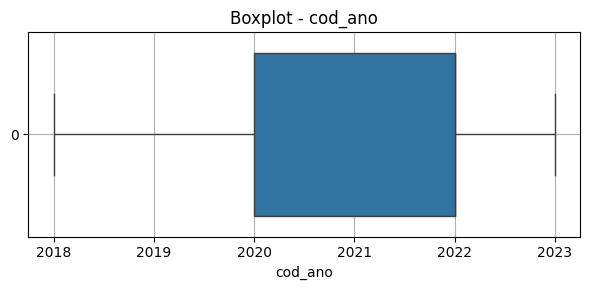

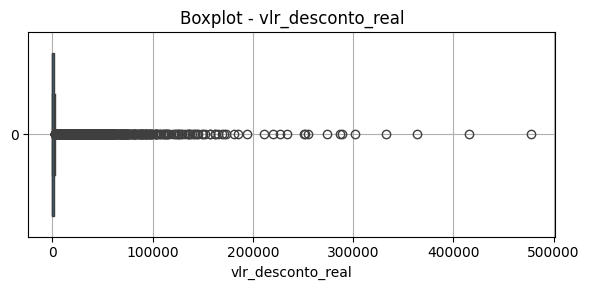

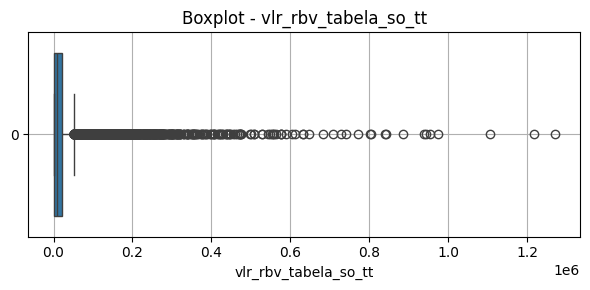

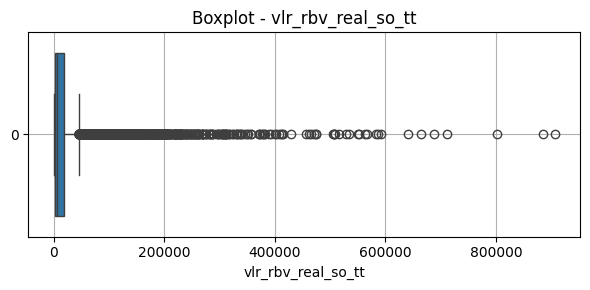

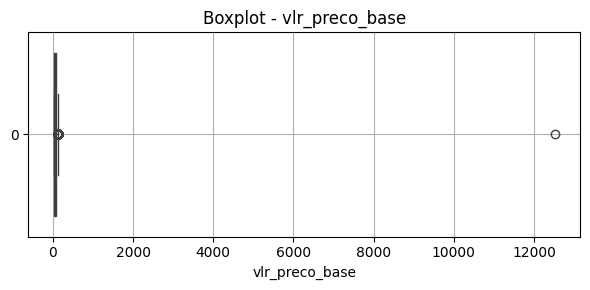

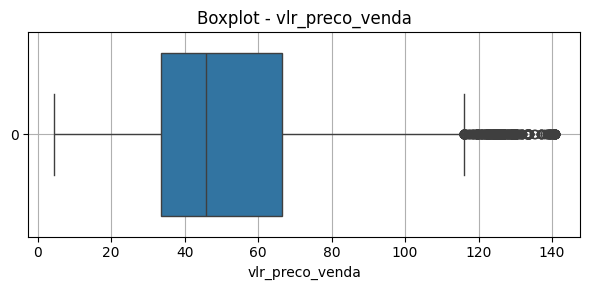

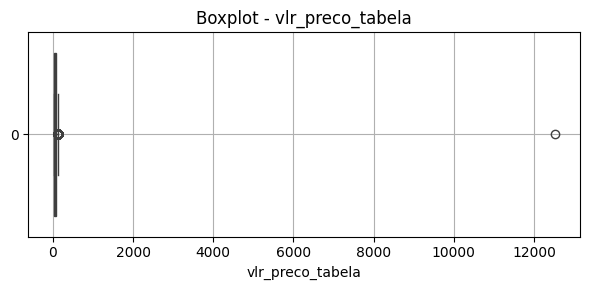

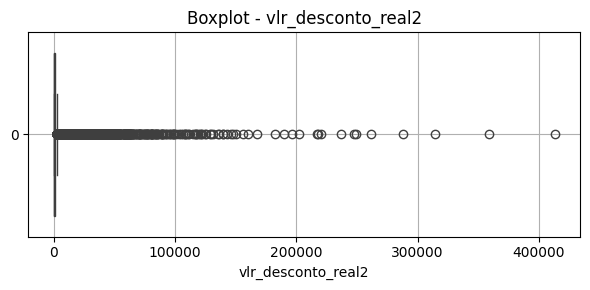


Outliers were kept, as they may represent real business scenarios (e.g., aggressive promotions).


In [23]:
# Boxplots for visualization
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")

    formatter = mticker.StrMethodFormatter('{x:,.0f}')
    plt.gca().yaxis.set_major_formatter(formatter)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nOutliers were kept, as they may represent real business scenarios (e.g., aggressive promotions).")

# 4 - Load to BigQuery

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
uploaded = files.upload()

# Load secrets file
secrets_content = uploaded["secrets.json"]
secrets = json.loads(secrets_content)

project_id = secrets["project_id"]
dataset_id = secrets["dataset_id"]

Saving secrets.json to secrets.json


In [ ]:
# Define schema
schema = [
    SchemaField("cod_ciclo", "STRING"),
    SchemaField("cod_ano", "INTEGER"),
    SchemaField("cod_canal", "STRING"),
    SchemaField("cod_agrupador_sap_material", "STRING"),
    SchemaField("cod_regional_agrupador", "STRING"),
    SchemaField("cod_uf", "STRING"),
    SchemaField("des_categoria_material", "STRING"),
    SchemaField("des_subcategoria_material", "STRING"),
    SchemaField("des_marca_material", "STRING"),
    SchemaField("des_tier", "STRING"),
    SchemaField("des_mecanica_consumidor", "STRING"),
    SchemaField("des_mecanica_rev", "STRING"),
    SchemaField("des_promocao_publico", "STRING"),
    SchemaField("vlr_desconto_real", "FLOAT"),
    SchemaField("vlr_rbv_tabela_so_tt", "FLOAT"),
    SchemaField("vlr_rbv_real_so_tt", "FLOAT"),
    SchemaField("vlr_preco_base", "FLOAT"),
    SchemaField("vlr_preco_venda", "FLOAT"),
    SchemaField("vlr_preco_tabela", "FLOAT"),
    SchemaField("vlr_desconto_real2", "FLOAT")
]

In [24]:
client = bigquery.Client(project=project_id)

table_ref = client.dataset(dataset_id).table("promotions_products")

job_config = bigquery.LoadJobConfig(
    schema=schema,
    write_disposition="WRITE_TRUNCATE",
)

job = client.load_table_from_dataframe(df, table_ref, job_config=job_config)
job.result()

print("✅ Data successfully loaded into BigQuery")

✅ Data successfully loaded into BigQuery
